# BKT Transition: Vortices, Helicity, and Correlations

The Berezinskii-Kosterlitz-Thouless (BKT) transition in the 2D XY model is not driven by symmetry breaking but by the unbinding of topological defects, vortex-antivortex pairs. Below $T_{\mathrm{BKT}} \approx 0.893$ (the Monte Carlo estimate is $0.8933(6)$ [[4]](#Bibliography)) vortices and antivortices remain bound into dipole pairs that contribute only weakly to thermodynamic fluctuations. Above $T_{\mathrm{BKT}}$ these pairs dissociate into free vortices, which destroy the algebraic quasi-long-range order and introduce a finite correlation length [[1]](#Bibliography) [[2]](#Bibliography).

This notebook examines three equilibrium signatures of the transition. The vortex density $n_v(T)$ counts the fraction of plaquettes carrying a nonzero winding number and rises steeply around $T_{\mathrm{BKT}}$ as pairs proliferate and unbind. The helicity modulus $\Upsilon(T)$, the superfluid stiffness, drops to zero at the transition in the thermodynamic limit, and its value just below the transition is fixed by the universal relation $\Upsilon(T_{\mathrm{BKT}}^{-}) = 2T_{\mathrm{BKT}}/\pi$ derived by Nelson and Kosterlitz from the renormalization-group flow of the vortex gas [[3]](#Bibliography). The correlation function $G(r)$ decays algebraically as $r^{-\eta(T)}$ with a continuously varying exponent below $T_{\mathrm{BKT}}$ and exponentially as $e^{-r/\xi}$ above it [[1]](#Bibliography) [[2]](#Bibliography). All three follow from the same defect physics, so they should place the transition in the same temperature window.

Each section loads precomputed data from `../results/xy/` when available and otherwise falls back to a lightweight inline computation with one seed per temperature. The stored outputs in this notebook come from that fallback path.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from models.xy_model import XYSimulation
from utils.equilibration import prepare_equilibrated_simulation
from utils.observables import simulate_equilibrium_correlation

# Cache paths are relative to notebooks/, the directory the notebook runs from.
T_BKT = 0.893
CACHE_DIR = Path('../results/xy')
PALETTE = {
    'vortex': '#D65F5F',
    'helicity': '#4878CF',
    'corr_low': '#4878CF',
    'corr_high': '#D65F5F',
    'jump_line': '#956CB4',
}

plt.rcParams['figure.dpi'] = 120

print(f'T_BKT (theoretical) = {T_BKT}')
print(f'Cache directory: {CACHE_DIR}')


T_BKT (theoretical) = 0.893
Cache directory: ../results/xy


## Part I: Vortex Density

### Data

The vortex density is the fraction of lattice plaquettes that carry a nonzero winding number. In the ground state this fraction is zero. As $T$ increases, thermally generated vortex-antivortex pairs appear at a rate that grows rapidly near $T_{\mathrm{BKT}}$. The cached data comes from `scripts/xy/bkt_transition.py`. The fallback sweeps a $32 \times 32$ lattice over 18 temperatures between $T = 0.3$ and $T = 1.5$. At each temperature a random start and an ordered start are evolved with independent seeds until their traces agree (at most 20,000 sweeps, checked every 200), and the random start is then measured; stuck detection is switched off because the XY model has no stranded domain states, and the ordered start is used only if the pair never converges. The density is averaged over 80 sweeps per point, which is short enough that point-to-point noise is visible.

In [2]:
vortex_cache = CACHE_DIR / 'bkt_transition.npz'
vortex_min_points = 8


def _compute_vortex_sweep(
    *,
    size: int = 32,
    n_temps: int = 18,
    meas_steps: int = 80,
    eq_probe: int = 200,
    eq_max: int = 20_000,
) -> tuple[np.ndarray, np.ndarray]:
    temps = np.linspace(0.3, 1.5, n_temps)
    densities = np.empty_like(temps)
    for idx, t in enumerate(temps):
        # Two independent starts run until they agree; the XY model has no
        # stranded domain states, so stuck detection stays off. A pair that
        # never converges is not measured and gives NaN.
        sim, outcome = prepare_equilibrated_simulation(
            model_cls=XYSimulation, model_kwargs={}, size=size, temp=float(t), seed=100 + idx,
            chunk_size=eq_probe, max_steps=eq_max, detect_stuck=False,
        )
        if not outcome.certified:
            densities[idx] = np.nan
            continue
        total = 0.0
        for _ in range(meas_steps):
            sim.step()
            total += sim.get_vortex_density()
        densities[idx] = total / meas_steps
    return temps, densities


vortex_loaded = False
if vortex_cache.exists():
    d = np.load(vortex_cache)
    if 'temperatures' in d.files and 'vortex_densities' in d.files and d['temperatures'].size >= vortex_min_points:
        vortex_temps = np.asarray(d['temperatures'], dtype=float)
        vortex_densities = np.asarray(d['vortex_densities'], dtype=float)
        vortex_source = f'Loaded {vortex_temps.size} points from cache ({vortex_cache.name})'
        vortex_loaded = True

if not vortex_loaded:
    vortex_temps, vortex_densities = _compute_vortex_sweep()
    vortex_source = f'Computed fallback vortex sweep ({vortex_temps.size} points, L=32)'

print(vortex_source)

Computed fallback vortex sweep (18 points, L=32)


### Vortex Density vs Temperature

The figure plots $n_v(T)$ from the code cell below, with the dashed vertical line at $T_{\mathrm{BKT}} = 0.893$. In the fallback run the density is zero to plotting precision up to $T \approx 0.65$ and stays below about $0.01$ up to $T \approx 0.87$: the few thermally excited vortices sit in tightly bound pairs. Just above $T_{\mathrm{BKT}}$ it reaches about $0.02$ and then rises steeply to $0.137$ at $T = 1.5$. The small dips at $T \approx 0.87$ and $T \approx 1.0$ are noise from the 80-sweep average, not structure. The density itself is smooth through the transition, since it counts all vortices whether bound or free, so the figure shows where defects proliferate rather than a sharp critical point. At $T = 1.5$ the value is still well below the random-phase limit $n_v \to 1/3$, which is the density for independent, uniformly distributed angles and is reached only as $T \to \infty$.

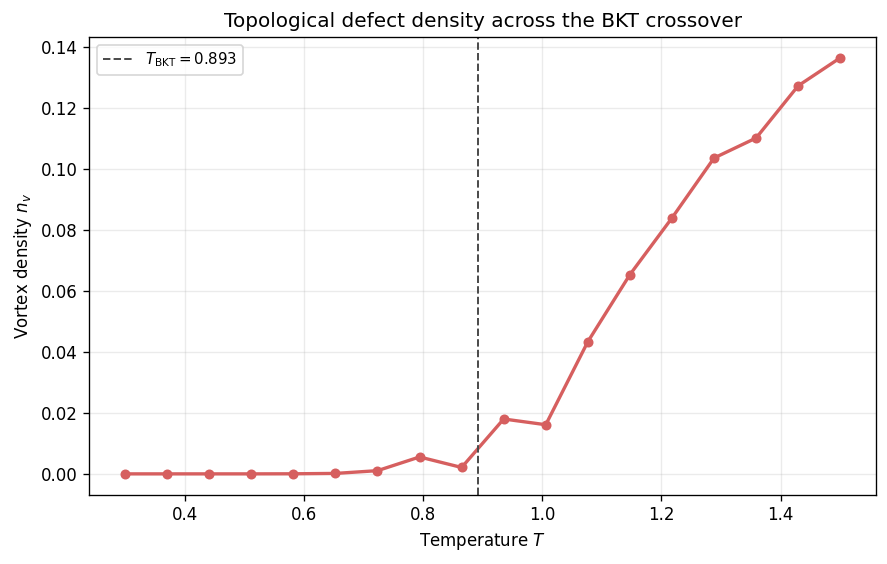

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(vortex_temps, vortex_densities, 'o-', color=PALETTE['vortex'], lw=2, ms=5)
ax.axvline(T_BKT, color='0.3', ls='--', lw=1.2, label=rf'$T_{{\mathrm{{BKT}}}} = {T_BKT}$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel('Vortex density $n_v$')
ax.set_title('Topological defect density across the BKT crossover')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Part II: Helicity Modulus

### Data

The helicity modulus (superfluid stiffness) $\Upsilon$ measures the free-energy cost of imposing a twist across the lattice boundary. It is computed from the fluctuations of the spin-angle current:

$$\Upsilon = \frac{1}{L^2}\left( \langle C \rangle - \frac{1}{T}\langle S^2 \rangle \right)$$

where $C = \sum_{\langle i,j \rangle_x} \cos(\theta_i - \theta_j)$ and $S = \sum_{\langle i,j \rangle_x} \sin(\theta_i - \theta_j)$ are summed over nearest-neighbor bonds in the $x$-direction.

The BKT theory predicts a universal jump: $\Upsilon(T_{\mathrm{BKT}}^-) = 2T_{\mathrm{BKT}}/\pi$ with $\Upsilon = 0$ above the transition in the thermodynamic limit [[3]](#Bibliography). On finite lattices the jump is rounded into a smooth crossover, and the temperature where $\Upsilon(T)$ crosses the line $2T/\pi$ lies above $T_{\mathrm{BKT}}$. Because the correlation length diverges as $\exp(b/\sqrt{t})$ with $t = (T - T_{\mathrm{BKT}})/T_{\mathrm{BKT}}$, such finite-size estimates approach $T_{\mathrm{BKT}}$ only as $(\ln L)^{-2}$ [[2]](#Bibliography) [[4]](#Bibliography).

The cached data comes from `scripts/xy/helicity_modulus.py`. The fallback uses a $32 \times 32$ lattice and 20 temperatures between $T = 0.1$ and $T = 1.5$, with the same two-start equilibration as Part I (stuck detection off) followed by 2,000 measurement sweeps per point.

In [4]:
helicity_cache = CACHE_DIR / 'helicity_modulus.npz'
helicity_min_points = 8


def _compute_helicity_sweep(
    *,
    size: int = 32,
    n_temps: int = 20,
    meas_steps: int = 2_000,
    eq_probe: int = 200,
    eq_max: int = 20_000,
) -> tuple[np.ndarray, np.ndarray]:
    temps = np.linspace(0.1, 1.5, n_temps)
    helicity = np.empty_like(temps)
    for idx, t in enumerate(temps):
        sim, outcome = prepare_equilibrated_simulation(
            model_cls=XYSimulation, model_kwargs={}, size=size, temp=float(t), seed=200 + idx,
            chunk_size=eq_probe, max_steps=eq_max, detect_stuck=False,
        )
        if not outcome.certified:
            # The pair never converged, so the point is not measured.
            helicity[idx] = np.nan
            continue
        cos_sums = np.empty(meas_steps)
        sin_sums = np.empty(meas_steps)
        for k in range(meas_steps):
            sim.step()
            cos_sums[k], sin_sums[k] = sim.get_helicity_data()
        avg_cos = np.mean(cos_sums)
        avg_sq_sin = np.mean(sin_sums ** 2)
        helicity[idx] = (avg_cos - (1.0 / float(t)) * avg_sq_sin) / (size ** 2)
    return temps, helicity


helicity_loaded = False
if helicity_cache.exists():
    d = np.load(helicity_cache)
    if 'temperatures' in d.files and 'helicity_modulus' in d.files and d['temperatures'].size >= helicity_min_points:
        helicity_temps = np.asarray(d['temperatures'], dtype=float)
        helicity_vals = np.asarray(d['helicity_modulus'], dtype=float)
        helicity_source = f'Loaded {helicity_temps.size} points from cache ({helicity_cache.name})'
        helicity_loaded = True

if not helicity_loaded:
    helicity_temps, helicity_vals = _compute_helicity_sweep()
    helicity_source = f'Computed fallback helicity sweep ({helicity_temps.size} points, L=32)'

print(helicity_source)

Computed fallback helicity sweep (20 points, L=32)


### Helicity Modulus vs Temperature

The figure plots $\Upsilon(T)$ together with the line $2T/\pi$ (dashed purple) and $T_{\mathrm{BKT}} = 0.893$ (dashed grey). In the fallback run $\Upsilon$ falls monotonically from about $0.98$ at $T = 0.1$, slowly at first as spin waves soften the stiffness and faster as bound vortex pairs start to screen it, to about $0.61$ at $T \approx 0.91$ and $0.53$ at $T \approx 0.98$. It crosses the $2T/\pi$ line between these two points, near $T \approx 0.93$. That crossing is the finite-size estimate of the transition temperature on $L = 32$; it lies above $T_{\mathrm{BKT}} = 0.893$ as expected from the logarithmic finite-size shift. Between $T \approx 0.98$ and $T \approx 1.06$ the stiffness collapses to about $0.07$, the rounded remnant of the universal jump. Above that the values scatter around zero, between about $-0.18$ and $+0.07$. A negative stiffness has no physical meaning here: the estimator is the difference of two large fluctuating terms, and 2,000 sweeps at one seed do not average $\langle S^2 \rangle / T$ down to the precision needed when the true $\Upsilon$ is close to zero. The lower axis limit is widened automatically so that these points stay visible.

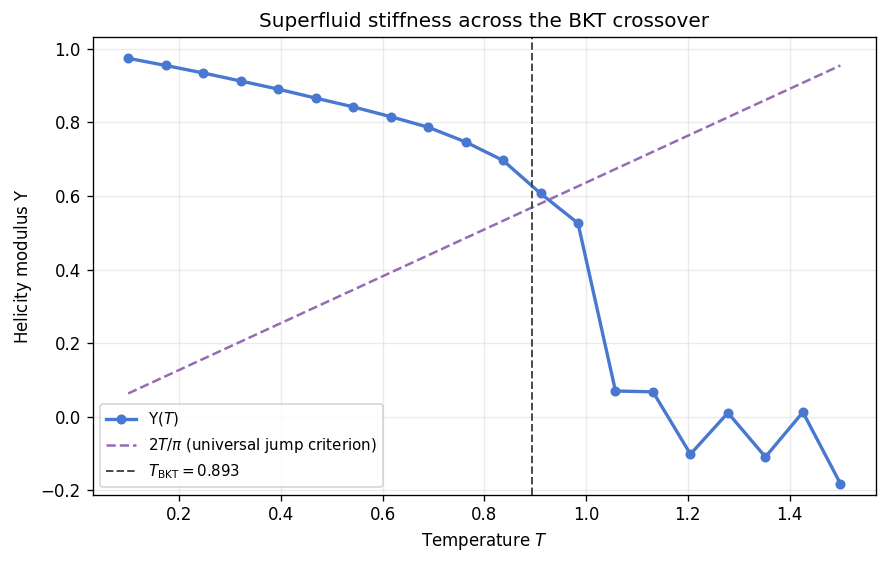

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(helicity_temps, helicity_vals, 'o-', color=PALETTE['helicity'], lw=2, ms=5, label=r'$\Upsilon(T)$')

jump_line_t = np.linspace(helicity_temps.min(), helicity_temps.max(), 100)
jump_line_y = 2.0 * jump_line_t / np.pi
ax.plot(jump_line_t, jump_line_y, '--', color=PALETTE['jump_line'], lw=1.5, label=r'$2T/\pi$ (universal jump criterion)')

ax.axvline(T_BKT, color='0.3', ls='--', lw=1.2, label=rf'$T_{{\mathrm{{BKT}}}} = {T_BKT}$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'Helicity modulus $\Upsilon$')
ax.set_title('Superfluid stiffness across the BKT crossover')
# Widen the lower limit when finite-sample scatter above T_BKT drives points below -0.05.
ax.set_ylim(bottom=min(-0.05, float(np.min(helicity_vals)) - 0.03))
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Part III: Correlation Function

### Data

The spin-spin correlation function $G(r) = \langle \vec{s}_0 \cdot \vec{s}_r \rangle$, normalized to $G(0) = 1$, reveals the nature of order in each regime. Below $T_{\mathrm{BKT}}$ the decay is algebraic, $G(r) \sim r^{-\eta(T)}$, with $\eta = T/(2\pi \Upsilon_R)$ set by the renormalized stiffness $\Upsilon_R$ and reaching $\eta(T_{\mathrm{BKT}}) = 1/4$. At low temperature $\Upsilon_R \approx J$ and the spin-wave approximation $\eta \approx T/(2\pi J)$ holds. Above $T_{\mathrm{BKT}}$ the decay is exponential, $G(r) \sim \exp(-r/\xi)$, with a correlation length that diverges as $\exp(b/\sqrt{t})$ on approach to the transition [[1]](#Bibliography) [[2]](#Bibliography) [[3]](#Bibliography). The precomputed data comes from `scripts/xy/correlation_comparison.py`. The fallback calls the shared helper `simulate_equilibrium_correlation` on a $64 \times 64$ lattice at $T = 0.4$ and $T = 1.5$: two-start equilibration for at most 6,000 sweeps, then 6,000 measurement sweeps with a correlation sample every 20 sweeps.

In [6]:
corr_cache = CACHE_DIR / 'correlation_comparison.npz'
T_LOW = 0.4
T_HIGH = 1.5


# Fallback resolution: raised from L=40 now that the shared helper falls back to
# the ordered start, which keeps G(r) meaningful at this size.
_corr_size = 64
_corr_steps = 6_000

def _compute_correlations(
    *,
    temp: float,
    size: int = _corr_size,
    total_steps: int = _corr_steps,
    sample_interval: int = 20,
    eq_probe: int = 200,
    eq_max: int = 6_000,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    # Shared helper: two-start convergence with an ordered-start fallback. Without
    # it a random start stranded by the stuck detector distorts G(r) badly at
    # larger L, which is what previously capped this fallback at L = 40.
    r, G = simulate_equilibrium_correlation(
        model_cls=XYSimulation, model_kwargs={}, size=size, temp=temp, seed=seed,
        eq_probe=eq_probe, eq_max=eq_max, meas_steps=total_steps,
        interval=sample_interval,
    )
    return np.asarray(r, dtype=float), np.asarray(G, dtype=float)


corr_loaded = False
if corr_cache.exists():
    d = np.load(corr_cache)
    if all(k in d.files for k in ('r_low', 'G_low', 'r_high', 'G_high')):
        r_low = np.asarray(d['r_low'], dtype=float)
        G_low = np.asarray(d['G_low'], dtype=float)
        r_high = np.asarray(d['r_high'], dtype=float)
        G_high = np.asarray(d['G_high'], dtype=float)
        T_LOW = float(d['T_low']) if 'T_low' in d.files else T_LOW
        T_HIGH = float(d['T_high']) if 'T_high' in d.files else T_HIGH
        corr_source = f'Loaded correlation data from cache ({corr_cache.name})'
        corr_loaded = True

if not corr_loaded:
    r_low, G_low = _compute_correlations(temp=T_LOW, seed=400)
    r_high, G_high = _compute_correlations(temp=T_HIGH, seed=401)
    corr_source = (
        f'Computed fallback correlations at L={_corr_size}, '
        f'{_corr_steps} measurement steps (reduced for interactive runtime)'
    )

print(corr_source)

Computed fallback correlations at L=64, 6000 measurement steps (reduced for interactive runtime)


### Correlation Functions on Log-Log and Semi-Log Scales

A log-log plot shows algebraic decay as a straight line whose negative slope is $\eta(T)$, while a semi-log plot shows exponential decay as a straight line with slope $-1/\xi$. The code cell below draws both views; points with $G(r) \le 0$ cannot appear on a logarithmic axis and are dropped.

At $T = 0.4$ the fallback curve is nearly flat on both scales. It falls from about $0.88$ at $r = 1$ to about $0.72$ at $r = 31$, a log-log slope of roughly $0.06$, which is comparable to the spin-wave value $T/(2\pi J) \approx 0.064$. The curve flattens further as $r$ approaches $L/2 = 32$ because periodic boundaries connect each pair of sites along two paths. At $T = 1.5$ the semi-log curve is close to a straight line from $r = 1$ to $r \approx 9$, where $G$ drops from about $0.3$ to about $2 \times 10^{-3}$, a decay length of order $1.5$ lattice spacings. On the log-log axes the same data bends downward, which rules out a power law. Beyond $r \approx 10$ the signal reaches a noise floor near $10^{-3}$ set by the 300 samples, and from $r = 20$ on the estimates are no longer positive, which is why the curve ends there.

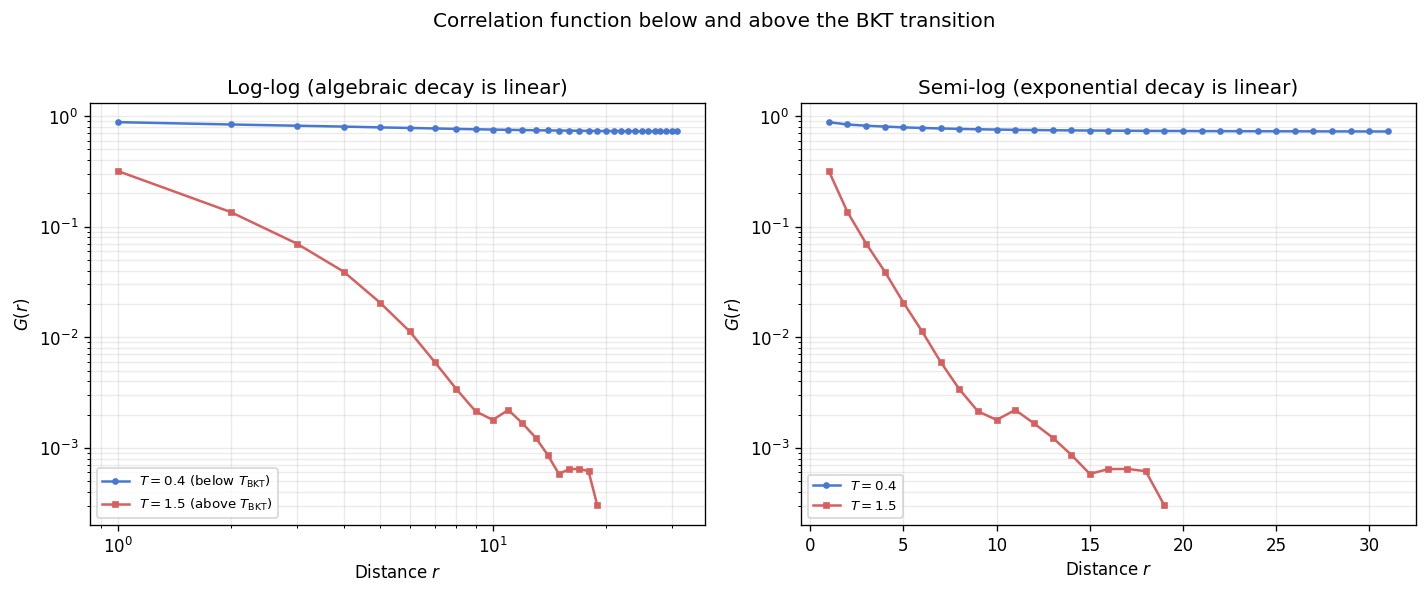

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

mask_low = (r_low > 0) & (G_low > 0)
mask_high = (r_high > 0) & (G_high > 0)

# Log-log: algebraic regime
axes[0].loglog(r_low[mask_low], G_low[mask_low], 'o-', color=PALETTE['corr_low'], ms=3, lw=1.5,
               label=rf'$T = {T_LOW}$ (below $T_{{\mathrm{{BKT}}}}$)')
axes[0].loglog(r_high[mask_high], G_high[mask_high], 's-', color=PALETTE['corr_high'], ms=3, lw=1.5,
               label=rf'$T = {T_HIGH}$ (above $T_{{\mathrm{{BKT}}}}$)')
axes[0].set_xlabel('Distance $r$')
axes[0].set_ylabel('$G(r)$')
axes[0].set_title('Log-log (algebraic decay is linear)')
axes[0].grid(alpha=0.25, which='both')
axes[0].legend(fontsize=8)

# Semi-log: exponential regime
axes[1].semilogy(r_low[mask_low], G_low[mask_low], 'o-', color=PALETTE['corr_low'], ms=3, lw=1.5,
                 label=rf'$T = {T_LOW}$')
axes[1].semilogy(r_high[mask_high], G_high[mask_high], 's-', color=PALETTE['corr_high'], ms=3, lw=1.5,
                 label=rf'$T = {T_HIGH}$')
axes[1].set_xlabel('Distance $r$')
axes[1].set_ylabel('$G(r)$')
axes[1].set_title('Semi-log (exponential decay is linear)')
axes[1].grid(alpha=0.25, which='both')
axes[1].legend(fontsize=8)

fig.suptitle('Correlation function below and above the BKT transition', y=1.02)
fig.tight_layout()
plt.show()

## Synthesis

The three observables locate the BKT mechanism in the same temperature window, with the caveat that each comes from one seed on a small lattice. The vortex density stays below about $0.01$ up to $T \approx 0.87$ and rises steeply just above $T_{\mathrm{BKT}}$, the defect-proliferation signature. The helicity modulus falls from about $0.98$ and crosses the $2T/\pi$ line near $T \approx 0.93$ on $L = 32$, above $T_{\mathrm{BKT}} = 0.893$ by the expected finite-size shift, before collapsing to values that scatter around zero. The correlation function, measured only at $T = 0.4$ and $T = 1.5$, brackets the transition: a nearly flat algebraic decay with a small exponent below it and exponential decay with a decay length of order 1.5 lattice spacings well above it. In the thermodynamic limit these signatures distinguish the BKT transition from a conventional order-disorder transition: the correlation length diverges exponentially rather than as a power law from the high-temperature side, and the helicity modulus jumps discontinuously from $2T_{\mathrm{BKT}}/\pi$ to zero rather than vanishing continuously. On the finite lattices used here the jump appears as a steep but smooth drop.

## Bibliography

[[1]](#Bibliography) V. L. Berezinskii, "Destruction of Long-range Order in One-dimensional and Two-dimensional Systems Possessing a Continuous Symmetry Group. II. Quantum Systems," *Soviet Physics JETP* 34, 610 (1972). [JETP link](http://www.jetp.ras.ru/cgi-bin/e/index/e/34/3/p610?a=list)

[[2]](#Bibliography) J. M. Kosterlitz and D. J. Thouless, "Ordering, metastability and phase transitions in two-dimensional systems," *Journal of Physics C* 6, 1181 (1973). [IOP](https://iopscience.iop.org/article/10.1088/0022-3719/6/7/010)

[[3]](#Bibliography) D. R. Nelson and J. M. Kosterlitz, "Universal Jump in the Superfluid Density of Two-Dimensional Superfluids," *Physical Review Letters* 39, 1201 (1977). [APS](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.39.1201)

[[4]](#Bibliography) Y. Tomita and Y. Okabe, "Probability-changing cluster algorithm for two-dimensional XY and clock models," 2002. [arXiv:cond-mat/0202161](https://arxiv.org/abs/cond-mat/0202161)